# FairFace Inference Demo

## Imports

In [1]:
import torch
import matplotlib.pyplot as plt

import os
import csv

from PIL import Image

from fairface_vit import FairFaceViT
from training.losses import corn_label_from_logits  # adjust path to match your package layout

from model.siglip import model as siglip_model, processor as siglip_processor
from model.clip   import model as clip_model,   processor as clip_processor
from model.dinov2 import model as dinov2_model, processor as dinov2_processor

/home/ashkanrn/01-Project/University/Deep-Learning/DL-project/.venv/lib64/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
Loading weights: 100%|██████████| 208/208 [00:00<00:00, 3167.20it/s]
[transformers] SiglipVisionModel LOAD REPORT from: ../models/siglip-base-patch16-224
Key                                                          | Status     |  | 
-------------------------------------------------------------+------------+--+-
text_model.encoder.layers.{0...11}.self_attn.out_proj.bias   | UNEXPECTED |  | 
text_model.encoder.layers.{0...11}.mlp.fc1.weight            | UNEXPECTED |  | 
text_model.encoder.layers.{0...11}.self_attn.k_proj.bias     | UNEXPECTED |  | 
text_model.final_layer_norm.weight                           | UNEXPECTED |  | 
text_model.encoder.layers.{0...11}.mlp.fc2.weight            |

## Class Labels

In [2]:
gender_class = ["Male", "Female"]

age_class = ["0-2", "3-9", "10-19", "20-29", "30-39", "40-49",
              "50-59", "60-69", "more than 70"]

race_class = ["East Asian", "Indian", "Black", "White", "Middle Eastern",
               "Latino_Hispanic", "Southeast Asian"]

## Utility Functions

### Checkpoint Loading

In [3]:
def load_checkpoint(model_builder_fn, model_name, run_version, device):
    """
    Load the trained classification heads from a saved checkpoint.

    model_builder_fn: a zero-arg callable that returns a fresh FairFaceViT
                       instance once we know age_loss_type, e.g.:
                       lambda age_loss_type: FairFaceViT(clip_model, age_loss_type=age_loss_type)
    """
    checkpoint = torch.load(
        f"../checkpoints/{model_name}/{run_version}/{model_name}-best-heads.pt",
        map_location=device
    )

    age_loss_type = checkpoint.get("age_loss_type", "ce")  # old checkpoints default to "ce"

    model = model_builder_fn(age_loss_type)

    model.gender.load_state_dict(checkpoint["gender_head"])
    model.age.load_state_dict(checkpoint["age_head"])
    model.race.load_state_dict(checkpoint["race_head"])

    model.to(device)
    model.eval()

    return model, age_loss_type

### Core Inference

The model outputs logits, which are converted into probabilities:

- Sigmoid is used for binary gender classification.
- Softmax is used for multi-class age and race classification.

The class with the highest probability is selected as the final prediction.

In [4]:
def get_logits(model, processor, image, device):
    """
    Run inference on a single image and extract raw logits.

    Returns:
        Dictionary containing raw logits for each task.
    """
    # print(processor.to_dict())

    inputs = processor(
        images=image,
        return_tensors="pt"
    )

    pixel_values = inputs["pixel_values"].to(device)

    with torch.no_grad():
        outputs = model(pixel_values)

    # LOGITS
    return {
        'gender': outputs["gender"],
        'age': outputs["age"],
        'race': outputs["race"]
    }

In [5]:
def get_prediction_results(logits, age_loss_type="ce"):
    """
    Convert model logits into human-readable predictions.

    Applies:
    - Sigmoid for binary gender classification.
    - Softmax for age and race multi-class classification.

    The class with the highest probability is selected as prediction.

    Args:
        logits: Dictionary containing model outputs.

    Returns:
        Dictionary containing predicted classes and confidence scores.
    """

    # --- Gender (binary, sigmoid) ---
    gender_prob = torch.sigmoid(logits['gender']).item()
    gender_idx = int(gender_prob > 0.5)
    gender_probs = [1 - gender_prob, gender_prob]

    # --- Age (multi-class, softmax) ---
    if age_loss_type == "corn":
        age_logits = logits['age']                          # (1, 8)
        age_idx = corn_label_from_logits(age_logits).item()
        # per-class probs aren't naturally defined for CORN the way softmax gives them;
        # report the per-threshold "pass" probabilities instead for display purposes
        age_probs = torch.sigmoid(age_logits)[0].cpu().tolist()
        age_prob = None  # no single "confidence" scalar analogous to softmax max — see note below
    else:
        age_tensor = torch.softmax(logits['age'], dim=1)[0].cpu()
        age_idx = age_tensor.argmax().item()
        age_probs = age_tensor.tolist()
        age_prob = age_probs[age_idx]

    # age_tensor = torch.softmax(logits['age'], dim=1)[0].cpu()
    # age_idx = age_tensor.argmax().item()
    # age_probs = age_tensor.tolist()

    # --- Race (multi-class, softmax) ---
    race_tensor = torch.softmax(logits['race'], dim=1)[0].cpu()
    race_idx = race_tensor.argmax().item()
    race_probs = race_tensor.tolist()

    return {
        'gender':      gender_class[gender_idx],
        'gender_prob': gender_probs[gender_idx],

        'age':         age_class[age_idx],
        'age_prob':    age_prob,

        'race':        race_class[race_idx],
        'race_prob':   race_probs[race_idx],
    }

def print_ranked(category, class_names, probabilities, sort=True):
    """
    Display class probabilities.

    Used for visualizing single image predictions.

    Args:
        category: Prediction category name.
        class_names: List of class labels.
        probabilities: Probability for each class.
        sort: If True, sort descending and report the argmax as the prediction
              (correct for softmax outputs — gender, race, CE age).
              If False, print in the given order without implying that the
              highest value is the prediction (needed for CORN's threshold
              pass-probabilities, which are monotonically decreasing and
              whose "highest" entry is almost always the first threshold,
              not the actual predicted class).

    Returns:
        The class with the highest probability if sort=True, otherwise None.
    """
    print(f"\n{category}:")

    pairs = list(zip(class_names, probabilities))

    if sort:
        pairs.sort(key=lambda pair: pair[1], reverse=True)

    for name, prob in pairs:
        percentage = prob * 100
        print(f"  {name:<20}: {percentage:.2f}%")

    if sort:
        top_name = pairs[0][0]
        print(f"  -> Prediction: {top_name}")
        return top_name

    return None

### Visualization Utilities

In [6]:

def display_prediction(logits, name=None, age_loss_type="ce"):
    """
    Display prediction results for a single image.

    Shows probability ranking for:
    - Gender
    - Age
    - Race

    NOT used for CSV generation.

    Args:
        logits: Raw model outputs.
        name: Model name for display.
        age_loss_type: "ce" or "corn" — determines how age logits are decoded/displayed.
    """
    model_name = "" if name is None else name

    gender_prob = torch.sigmoid(logits['gender']).item()
    gender_probs = [1 - gender_prob, gender_prob]  # 0 -> Male, 1 -> Female

    if age_loss_type == "corn":
        age_idx = corn_label_from_logits(logits['age']).item()
        age_probs = torch.sigmoid(logits['age'])[0].cpu().tolist()
        # these are per-threshold "pass" probabilities, not per-class softmax probs —
        # they're monotonically decreasing by construction, so the max is NOT the prediction
    else:
        age_probs = torch.softmax(logits['age'], dim=1)[0].cpu().tolist()

    race_probs = torch.softmax(logits['race'], dim=1)[0].cpu().tolist()

    print(f"{'-'*5}{model_name} Prediction Result{'-'*5}")

    predictions = {
        "Gender": print_ranked("Gender", gender_class, gender_probs),
        "Age":    None,  # filled in below, branch depends on age_loss_type
        "Race":   print_ranked("Race", race_class, race_probs),
    }

    if age_loss_type == "corn":
        print_ranked(
            "Age (threshold pass-probs)",
            [f"> {c}" for c in age_class[:-1]],
            age_probs,
            sort=False
        )
        predicted_age = age_class[age_idx]
        print(f"  -> Predicted age bin: {predicted_age}")
        predictions["Age"] = predicted_age
    else:
        predictions["Age"] = print_ranked("Age", age_class, age_probs)

    print("\n\n")
    return predictions

In [7]:
def predict_image(model, processor, image_path, device, age_loss_type="ce"):
    image = Image.open(image_path).convert("RGB")
    logits = get_logits(model, processor, image, device)
    return get_prediction_results(logits, age_loss_type=age_loss_type)


def predict_folder(models_dict, folder_path, device, output_csv,
                    extensions=(".jpg", ".jpeg", ".png","webp")):
    """
    models_dict: {
                "clip": (model, processor),
                "dinov2": (model, processor),
                "siglip": (model, processor)
            }
    """
    image_files = sorted(
        f for f in os.listdir(folder_path)
        if f.lower().endswith(extensions)
    )

    fieldnames = ["image", "model", "gender", "gender_prob",
                  "age", "age_prob", "race", "race_prob"]

    with open(output_csv, "w", newline="") as f:
        writer = csv.DictWriter(f, fieldnames=fieldnames)
        writer.writeheader()

        for image_file in image_files:
            image_path = os.path.join(folder_path, image_file)

            for model_name, (model, processor, age_loss_type) in models_dict.items():
                result = predict_image(model, processor, image_path, device, age_loss_type=age_loss_type)
                writer.writerow({
                    "image": image_file,
                    "model": model_name,
                    **result,
                    
                })

    print(f"Saved predictions to {output_csv}")

## Load The Models

In [8]:
device = "cuda" if torch.cuda.is_available() else "cpu"

fairface_clipv2_model, clip_v2_age_type = load_checkpoint(
    lambda age_loss_type: FairFaceViT(clip_model, age_loss_type=age_loss_type),
    "clip", "v2", device
)

fairface_siglip_model, siglip_age_type = load_checkpoint(
    lambda age_loss_type: FairFaceViT(siglip_model, age_loss_type=age_loss_type),
    "siglip", "v2", device
)

fairface_dinov2_model, dinov2_age_type = load_checkpoint(
    lambda age_loss_type: FairFaceViT(dinov2_model, age_loss_type=age_loss_type),
    "dinov2", "v2", device
)

fairface_clip_corn_model, clip_corn_age_type = load_checkpoint(
    lambda age_loss_type: FairFaceViT(clip_model, age_loss_type=age_loss_type),
    "clip", "test", device
)

# fairface_clip_corn_model = load_checkpoint(FairFaceViT(clip_model, age_loss_type="corn"), "clip", "v3-corn", device)

# fairface_clipv2_1_model = load_checkpoint(
#     FairFaceViT(clip_model),
#     "clip",
#     "v2-1",
#     device
# )

In [9]:
models_dict = {
    "clip":         (fairface_clipv2_model, clip_processor, clip_v2_age_type),
    "dinov2":       (fairface_dinov2_model, dinov2_processor, dinov2_age_type),
    "siglip":       (fairface_siglip_model, siglip_processor, siglip_age_type),
    "clip-v3-corn": (fairface_clip_corn_model, clip_processor, clip_corn_age_type),
}

In [10]:
# print(fairface_clip_model)

## Folder Inference

In [11]:
predict_folder(models_dict, "../test-images/", device, "predictions.csv")

Saved predictions to predictions.csv


## Single Image Inference

In [14]:
image = Image.open("../test-images/ashkan.jpg").convert("RGB")



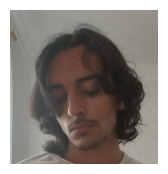

-----CLIP v3-CORN Prediction Result-----

Gender:
  Male                : 96.97%
  Female              : 3.03%
  -> Prediction: Male

Race:
  Middle Eastern      : 70.79%
  Indian              : 16.64%
  Latino_Hispanic     : 8.21%
  White               : 3.13%
  Southeast Asian     : 0.64%
  Black               : 0.40%
  East Asian          : 0.19%
  -> Prediction: Middle Eastern

Age (threshold pass-probs):
  > 0-2               : 99.99%
  > 3-9               : 99.74%
  > 10-19             : 78.39%
  > 20-29             : 10.93%
  > 30-39             : 5.77%
  > 40-49             : 7.30%
  > 50-59             : 6.98%
  > 60-69             : 3.45%
  -> Predicted age bin: 20-29





{'Gender': 'Male', 'Age': '20-29', 'Race': 'Middle Eastern'}

In [17]:
plt.figure(figsize=(3,2))
plt.imshow(image)
plt.axis('off')
plt.show()

device = "cuda" if torch.cuda.is_available() else "cpu"


clip_corn_logits = get_logits(fairface_clip_corn_model, clip_processor, image, device)
display_prediction(clip_corn_logits, 'CLIP v3-CORN', age_loss_type=clip_corn_age_type)

# clip_logits1 = get_logits(fairface_clipv2_model, clip_processor, image, device)
# display_prediction(clip_logits1,'CLIP v2')

# siglip_logits = get_logits(fairface_siglip_model, siglip_processor, image, device)
# display_prediction(siglip_logits,'SIGLIP v2')

# dinov2_logits = get_logits(fairface_dinov2_model, dinov2_processor, image, device)
# display_prediction(dinov2_logits,'DINOV2 v2')



# clip_logits2 = get_logits(fairface_clipv2_1_model, clip_processor, image, device)
# display_prediction(clip_logits2,'CLIP v2-1')